In [20]:
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from nbtools import auto_plot_style

from nbtools import normhist
from jupyfun import bin_centers

%matplotlib inline
auto_plot_style({"figure.figsize": (8,6)})

In [21]:
def gauss(x, area, mu, sigma):
    x = x - mu
    return area / (2*np.pi)**0.5 / sigma * np.exp(-x**2/2/sigma**2)

# Expected values

In [22]:
edrift                 = 1000 # V/cm
average_drift_time     = 4.05 # us
average_drift_velocity = 2.22 # mm/us
cm2s_to_mm2us          = 1e-4

dt = 37.368 * edrift**(0.093452) * np.exp(-8.1651e-5 * edrift)
dl = 66.350 * edrift**(-0.24855) + 36.85 * np.exp(-edrift / 35.661)

expected_td = (dt * 2 * average_drift_time * cm2s_to_mm2us                            )**0.5
expected_ld = (dl * 2 * average_drift_time * cm2s_to_mm2us / average_drift_velocity**2)**0.5

expected_td, expected_ld

(0.23064293036179265, 0.0442573084728252)

In [23]:
filename = "/home/gonzalo/sw/git/sentinel/test.csv"

*_, x, y, z, t = np.loadtxt(filename, skiprows=1).T

sigma = 0.2313872171686435 um


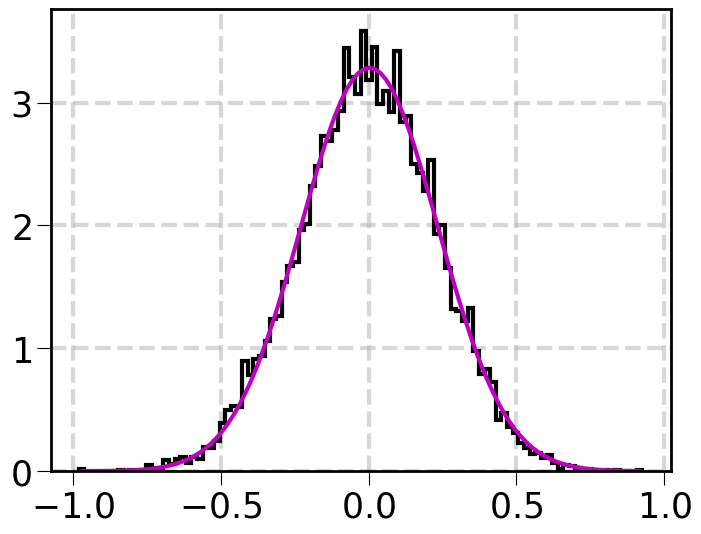

In [24]:
yc, xc, _ = normhist(x, 100)
xc        = bin_centers(xc)
values    = curve_fit(gauss, xc, yc, (1, 0, 1))[0]

plt.plot(xc, gauss(xc, *values))
print(f"sigma = {values[2]} um")
plt.grid()

sigma = 0.2326404448438839 um


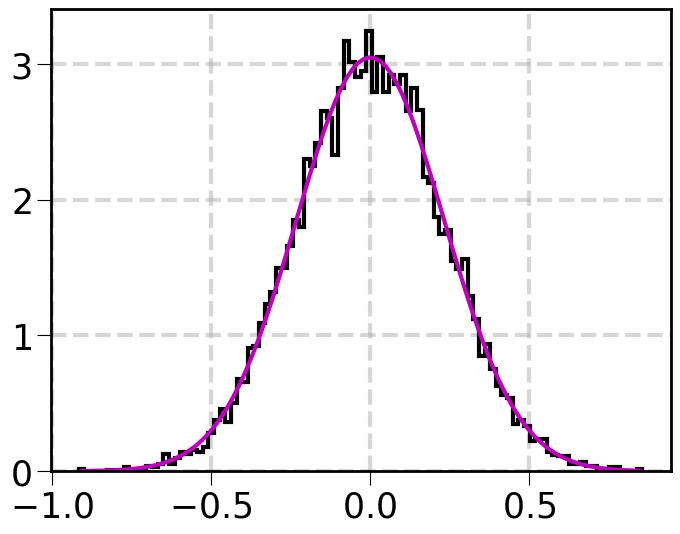

In [25]:
yc, xc, _ = normhist(y, 100)
xc        = bin_centers(xc)
values    = curve_fit(gauss, xc, yc, (1, 0, 1))[0]

plt.plot(xc, gauss(xc, *values))
print(f"sigma = {values[2]} um")
plt.grid()

sigma = 0.04462290086864353 us


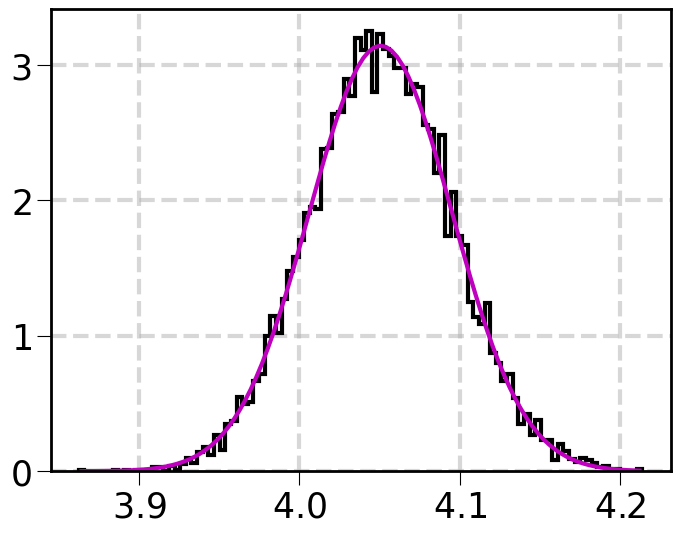

In [26]:
yc, xc, _ = normhist(t, 100)
xc        = bin_centers(xc)
values    = curve_fit(gauss, xc, yc, (1, 0, 1))[0]

plt.plot(xc, gauss(xc, *values))
print(f"sigma = {values[2]} us")
plt.grid()